# Austin Weather Data Analysis: Complete Data Cleaning & Feature Engineering


In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('default')
sns.set_palette("husl")


In [4]:
from google.colab import drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive/ADSCShade/

Mounted at /content/drive
/content/drive/MyDrive/ADSCShade


## Step 1: Load and Initial Data Inspection


In [3]:
# Load the weather data
data = pd.read_csv("Austin_Weather_99_23.csv")

print("=== INITIAL DATA OVERVIEW ===")
print(f"Dataset shape: {data.shape}")
print(f"Date range: {data['Date'].min()} to {data['Date'].max()}")
print("\nColumn names and data types:")
print(data.dtypes)
print("\nFirst 5 rows:")
data.head()


=== INITIAL DATA OVERVIEW ===
Dataset shape: (10354, 10)
Date range: 1/1/1999 to 9/9/2023

Column names and data types:
Date                       object
TempHighF                 float64
TempLowF                  float64
TempAvgF                  float64
DewPointAvgF               object
HumidityAvgPercent         object
sealevelpressure           object
VisibilityAvgMiles         object
PrecipitationSumInches    float64
Events                     object
dtype: object

First 5 rows:


,Date,TempHighF,TempLowF,TempAvgF,DewPointAvgF,HumidityAvgPercent,sealevelpressure,VisibilityAvgMiles,PrecipitationSumInches,Events
0,1/1/1999,73.9,51.8,60.5,57.9,92,1008.7,4.2,NaN,NaN
1,1/2/1999,64.3,37.2,48.2,30.4,52.1,1016.6,9.7,NaN,NaN
2,1/3/1999,39.7,30.3,35.6,12.1,39,1029.8,9.9,NaN,NaN
3,1/4/1999,42.8,28.0,34.2,13.9,43.7,1034.9,9.9,NaN,NaN
4,1/5/1999,55.5,21.4,39.7,31.4,72.6,1026.7,9.9,NaN,NaN


## Step 2: Comprehensive Missing Value Analysis


In [4]:
# Detailed missing value analysis
print("=== MISSING VALUE ANALYSIS ===")
missing_summary = data.isnull().sum()
missing_percentage = (missing_summary / len(data)) * 100

# Create table for missing values data
missing_df = pd.DataFrame({
    'Column': missing_summary.index,
    'Missing_Count': missing_summary.values,
    'Missing_Percentage': missing_percentage.values
})

print("Missing values by column:")
print(missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False))

# GPT
# Check for patterns in missing data
print("\nMissing value patterns:")
for col in data.columns:
    if data[col].isnull().sum() > 0:
        print(f"{col}: {data[col].isnull().sum()} missing values ({missing_percentage[col]:.2f}%)")


=== MISSING VALUE ANALYSIS ===
Missing values by column:
                   Column  Missing_Count  Missing_Percentage
9                  Events           6318           61.019896
8  PrecipitationSumInches            204            1.970253
4            DewPointAvgF              4            0.038632
7      VisibilityAvgMiles              4            0.038632
5      HumidityAvgPercent              1            0.009658

Missing value patterns:
DewPointAvgF: 4 missing values (0.04%)
HumidityAvgPercent: 1 missing values (0.01%)
VisibilityAvgMiles: 4 missing values (0.04%)
PrecipitationSumInches: 204 missing values (1.97%)
Events: 6318 missing values (61.02%)


## Step 3: Data Type Conversion and Cleaning


In [5]:
# Create a working copy for cleaning
data_clean = data.copy()

print("=== DATA TYPE CONVERSION ===")

# Convert Date column to datetime
data_clean['Date'] = pd.to_datetime(data_clean['Date'])

# Convert numeric columns that are stored as objects
numeric_columns = ['DewPointAvgF', 'HumidityAvgPercent', 'sealevelpressure', 'VisibilityAvgMiles']

for col in numeric_columns:
    if col in data_clean.columns:
        # Convert to numeric, replacing errors with NaN
        data_clean[col] = pd.to_numeric(data_clean[col], errors='coerce')
        print(f"Converted {col} to numeric")

# Verify data types
print("\nUpdated data types:")
print(data_clean.dtypes)


=== DATA TYPE CONVERSION ===
Converted DewPointAvgF to numeric
Converted HumidityAvgPercent to numeric
Converted sealevelpressure to numeric
Converted VisibilityAvgMiles to numeric

Updated data types:
Date                      datetime64[ns]
TempHighF                        float64
TempLowF                         float64
TempAvgF                         float64
DewPointAvgF                     float64
HumidityAvgPercent               float64
sealevelpressure                 float64
VisibilityAvgMiles               float64
PrecipitationSumInches           float64
Events                            object
dtype: object


## Step 4: Missing Value Treatment Strategy


In [6]:
print("=== MISSING VALUE TREATMENT STRATEGY ===")

# Forward fill for weather variables (weather persists)
weather_vars = ['TempHighF', 'TempLowF', 'TempAvgF', 'DewPointAvgF',
                'HumidityAvgPercent', 'sealevelpressure', 'VisibilityAvgMiles']

for var in weather_vars:
    if var in data_clean.columns:
        missing_before = data_clean[var].isnull().sum()
        # Forward fill (use previous day's value)
        data_clean[var] = data_clean[var].fillna(method='ffill')
        # Backward fill for any remaining missing values at the beginning
        data_clean[var] = data_clean[var].fillna(method='bfill')
        missing_after = data_clean[var].isnull().sum()
        print(f"{var}: {missing_before} to {missing_after} missing values")

# Zero fill for precipitation (no rain = 0)
if 'PrecipitationSumInches' in data_clean.columns:
    missing_before = data_clean['PrecipitationSumInches'].isnull().sum()
    data_clean['PrecipitationSumInches'] = data_clean['PrecipitationSumInches'].fillna(0)
    missing_after = data_clean['PrecipitationSumInches'].isnull().sum()
    print(f"PrecipitationSumInches: {missing_before} to {missing_after} missing values (filled with 0)")

# Zero fill for Events (no precipitation = no rain)
if 'Events' in data_clean.columns:
    missing_before = data_clean['Events'].isnull().sum()

    # Fill with 'None' for no weather events
    data_clean['Events'] = data_clean['Events'].fillna('None')
    missing_after = data_clean['Events'].isnull().sum()
    print(f"Events: {missing_before} to {missing_after} missing values (filled with 'None')")

# Confirming all missing values are filled
final_missing = data_clean.isnull().sum().sum()
print(f"\nTotal missing values remaining: {final_missing}")


=== MISSING VALUE TREATMENT STRATEGY ===
TempHighF: 0 to 0 missing values
TempLowF: 0 to 0 missing values
TempAvgF: 0 to 0 missing values
DewPointAvgF: 7 to 0 missing values
HumidityAvgPercent: 2 to 0 missing values
sealevelpressure: 3 to 0 missing values
VisibilityAvgMiles: 12 to 0 missing values
PrecipitationSumInches: 204 to 0 missing values (filled with 0)
Events: 6318 to 0 missing values (filled with 'None')

Total missing values remaining: 0


## Step 5: Data Quality Validation


In [7]:
print("=== DATA QUALITY VALIDATION ===")

# Check for unrealistic values
numeric_cols = data_clean.select_dtypes(include=[np.number]).columns

print("Data quality checks:")
for col in numeric_cols:
    if col != 'Date':  # Skip date column
        min_val = data_clean[col].min()
        max_val = data_clean[col].max()
        print(f"{col}: min={min_val:.2f}, max={max_val:.2f}")

# Check for duplicate dates
duplicate_dates = data_clean['Date'].duplicated().sum()
print(f"\nCount of Duplicate dates: {duplicate_dates}")

# GPT
# Check date continuity
date_range = pd.date_range(start=data_clean['Date'].min(), end=data_clean['Date'].max(), freq='D')
missing_dates = len(date_range) - len(data_clean)
print(f"Missing dates in sequence: {missing_dates}")

print("\nData quality validation complete")


# Notice the extreme low DewPointAvgF min value
# Notice the extreme high HumidityAvgPercent max value
# We have the exact number of duplicate dates as the missing dates
# Because of this, we can see that the duplicate dates are not due to missing data
# but rather due to the data being collected multiple times in a single day


=== DATA QUALITY VALIDATION ===
Data quality checks:
TempHighF: min=22.60, max=110.40
TempLowF: min=8.20, max=84.50
TempAvgF: min=15.70, max=95.10
DewPointAvgF: min=-0.70, max=76.50
HumidityAvgPercent: min=18.40, max=99.50
sealevelpressure: min=997.40, max=1044.60
VisibilityAvgMiles: min=1.10, max=10.00
PrecipitationSumInches: min=0.00, max=7.49

Count of Duplicate dates: 1319
Missing dates in sequence: -1319

Data quality validation complete


## Step 6: Feature Engineering - Creating New Variables


In [8]:
print("=== FEATURE ENGINEERING ===")

# Create a copy for feature engineering
data_features = data_clean.copy()

# 1. Extract time-based features
print("Creating time-based features...")
data_features['Year'] = data_features['Date'].dt.year
data_features['Month'] = data_features['Date'].dt.month
data_features['Day'] = data_features['Date'].dt.day
data_features['DayOfYear'] = data_features['Date'].dt.dayofyear
data_features['Season'] = data_features['Month'].map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                                                     3: 'Spring', 4: 'Spring', 5: 'Spring',
                                                     6: 'Summer', 7: 'Summer', 8: 'Summer',
                                                     9: 'Fall', 10: 'Fall', 11: 'Fall'})
print("Added: Year, Month, Day, DayOfYear, Season")

# 2. Create weather-derived features
print("Creating weather-derived features...")

# Daily temperature range
data_features['DailyTempRange'] = data_features['TempHighF'] - data_features['TempLowF']
print("Added: DailyTempRange")

# Temperature categories
data_features['TempCategory'] = pd.cut(data_features['TempAvgF'],
                                       bins=[-np.inf, 32, 50, 70, 85, np.inf],
                                       labels=['Freezing', 'Cold', 'Mild', 'Warm', 'Hot'])
print("Added: TempCategory")

# Humidity categories
data_features['HumidityCategory'] = pd.cut(data_features['HumidityAvgPercent'],
                                           bins=[0, 30, 50, 70, 90, 100],
                                           labels=['Very Dry', 'Dry', 'Moderate', 'Humid', 'Very Humid'])
print("Added: HumidityCategory")

# 3. Create polynomial features (squared terms)
print("Creating polynomial features...")
data_features['TempAvgF_squared'] = data_features['TempAvgF'] ** 2
data_features['HumidityAvgPercent_squared'] = data_features['HumidityAvgPercent'] ** 2
data_features['Pressure_squared'] = data_features['sealevelpressure'] ** 2
print("Added: TempAvgF_squared, HumidityAvgPercent_squared, Pressure_squared")

# 4. Create interaction features
print("Creating interaction features...")
data_features['HeatIndex'] = data_features['TempAvgF'] * data_features['HumidityAvgPercent']
data_features['TempPressure'] = data_features['TempAvgF'] * data_features['sealevelpressure']
print("Added: HeatIndex, TempPressure")

# 5. Create lag features (previous day's weather)
print("Creating lag features...")
data_features['PrevDayTemp'] = data_features['TempAvgF'].shift(1)
data_features['PrevDayHumidity'] = data_features['HumidityAvgPercent'].shift(1)
print("Added: PrevDayTemp, PrevDayHumidity")

# 6. Create rolling averages
print("Creating rolling averages...")
data_features['TempAvg_7day'] = data_features['TempAvgF'].rolling(window=7, min_periods=1).mean()
data_features['HumidityAvg_7day'] = data_features['HumidityAvgPercent'].rolling(window=7, min_periods=1).mean()
print("Added: TempAvg_7day, HumidityAvg_7day")

print(f"Original features: {len(data.columns)}")
print(f"New features: {len(data_features.columns) - len(data.columns)}")
print(f"Total features: {len(data_features.columns)}")


=== FEATURE ENGINEERING ===
Creating time-based features...
Added: Year, Month, Day, DayOfYear, Season
Creating weather-derived features...
Added: DailyTempRange
Added: TempCategory
Added: HumidityCategory
Creating polynomial features...
Added: TempAvgF_squared, HumidityAvgPercent_squared, Pressure_squared
Creating interaction features...
Added: HeatIndex, TempPressure
Creating lag features...
Added: PrevDayTemp, PrevDayHumidity
Creating rolling averages...
Added: TempAvg_7day, HumidityAvg_7day
Original features: 10
New features: 17
Total features: 27


## Step 7: Year-over-Year Temperature Comparison Analysis


In [9]:
print("=== YEAR-OVER-YEAR TEMPERATURE ANALYSIS ===")

# Create year-over-year comparison data
yoy_data = data_features.copy()

# Add week number for comparison
yoy_data['Week'] = yoy_data['Date'].dt.isocalendar().week
yoy_data['Year'] = yoy_data['Date'].dt.year

# Calculate yearly statistics
yearly_stats = yoy_data.groupby('Year').agg({
    'TempAvgF': ['mean', 'min', 'max', 'std'],
    'TempHighF': ['mean', 'max'],
    'TempLowF': ['mean', 'min'],
    'DailyTempRange': 'mean',
    'HumidityAvgPercent': 'mean',
    'PrecipitationSumInches': 'sum'
}).round(2)

# Flatten column names
yearly_stats.columns = ['_'.join(col).strip() for col in yearly_stats.columns]
yearly_stats = yearly_stats.reset_index()

print("Yearly temperature statistics:")
print(yearly_stats[['Year', 'TempAvgF_mean', 'TempHighF_max', 'TempLowF_min', 'DailyTempRange_mean']].head(10))


=== YEAR-OVER-YEAR TEMPERATURE ANALYSIS ===
Yearly temperature statistics:
   Year  TempAvgF_mean  TempHighF_max  TempLowF_min  DailyTempRange_mean
0  1999          69.03          104.0          21.4                23.80
1  2000          69.32          109.8          24.6                19.83
2  2001          67.18          101.8          25.0                20.31
3  2002          67.78          100.3          23.3                19.52
4  2003          68.47          108.5          22.8                19.89
5  2004          68.22           99.8          24.4                18.25
6  2005          69.17          106.8          23.6                20.64
7  2006          70.62          103.3          28.0                21.66
8  2007          67.78           98.7          23.5                18.52
9  2008          69.57          102.5          23.9                22.83


In [10]:
# Create month-by-month comparison across years
monthly_comparison = yoy_data.groupby(['Year', 'Month']).agg({
    'TempAvgF': 'mean',
    'TempHighF': 'max',
    'TempLowF': 'min',
    'DailyTempRange': 'mean'
}).round(2)

# Reset index for easier analysis
monthly_comparison = monthly_comparison.reset_index()

print("Monthly temperature comparison (sample):")
print(monthly_comparison.head(15))


Monthly temperature comparison (sample):
    Year  Month  TempAvgF  TempHighF  TempLowF  DailyTempRange
0   1999      1     54.78       80.7      21.4           24.28
1   1999      2     60.86       87.0      26.9           25.69
2   1999      3     61.51       86.0      30.4           20.42
3   1999      4     71.26       87.9      30.6           20.27
4   1999      5     75.37       93.4      46.9           18.28
5   1999      6     79.38       92.4      67.9           15.68
6   1999      7     80.78       98.0      68.3           19.65
7   1999      8     85.50      104.0      67.5           25.57
8   1999      9     78.41       98.8      46.3           27.21
9   1999     10     67.18       92.0      38.7           29.54
10  1999     11     60.46       85.4      28.3           30.68
11  1999     12     52.52       82.8      22.1           28.51
12  2000      1     54.35       86.9      24.6           20.54
13  2000      2     61.47       82.8      34.4           20.82
14  2000      

In [11]:
# Calculate temperature trends over time
print("=== TEMPERATURE TREND ANALYSIS ===")

# Annual average temperature trend
annual_temps = yoy_data.groupby('Year')['TempAvgF'].mean().reset_index()
annual_temps['TempTrend'] = annual_temps['TempAvgF'].rolling(window=5, min_periods=1).mean()

# Calculate year-over-year change
annual_temps['YoY_Change'] = annual_temps['TempAvgF'].diff()
annual_temps['YoY_Change_5yr'] = annual_temps['TempTrend'].diff()

print("Annual temperature trends:")
print(annual_temps[['Year', 'TempAvgF', 'TempTrend', 'YoY_Change', 'YoY_Change_5yr']].tail(10))


=== TEMPERATURE TREND ANALYSIS ===
Annual temperature trends:
    Year   TempAvgF  TempTrend  YoY_Change  YoY_Change_5yr
15  2014  68.557260  69.161727    0.468962       -0.157753
16  2015  69.354110  69.452714    0.796849        0.290986
17  2016  70.906148  69.456409    1.552038        0.003695
18  2017  71.770364  69.735236    0.864216        0.278827
19  2018  69.134521  69.944480   -2.635843        0.209245
20  2019  69.465205  70.126069    0.330685        0.181589
21  2020  70.550273  70.365302    1.085068        0.239233
22  2021  69.298904  70.043853   -1.251369       -0.321449
23  2022  69.890685  69.667918    0.591781       -0.375936
24  2023  74.249071  70.690828    4.358386        1.022910


## Step 8: Visualization of Year-over-Year Comparisons


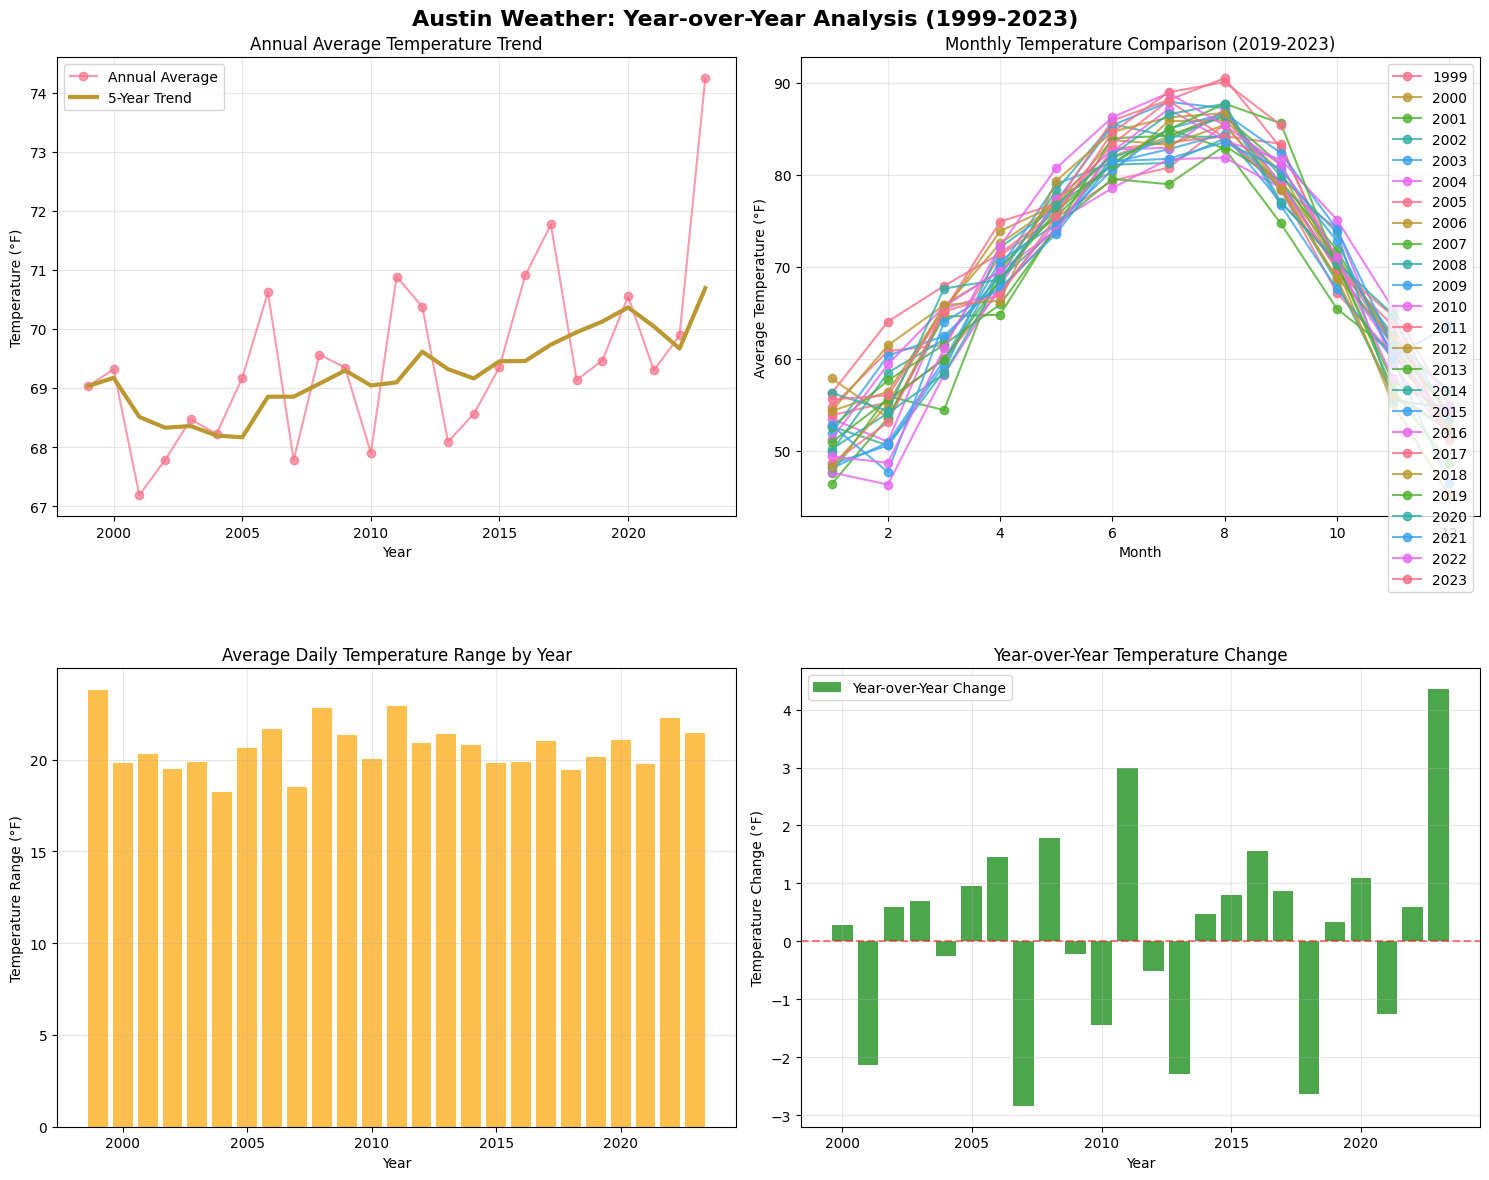

In [12]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Austin Weather: Year-over-Year Analysis (1999-2023)', fontsize=16, fontweight='bold')

# 1. Annual Average Temperature Trend
axes[0, 0].plot(annual_temps['Year'], annual_temps['TempAvgF'], 'o-', alpha=0.7, label='Annual Average')
axes[0, 0].plot(annual_temps['Year'], annual_temps['TempTrend'], '-', linewidth=3, label='5-Year Trend')
axes[0, 0].set_title('Annual Average Temperature Trend')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Temperature (°F)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Monthly Temperature Comparison (last 5 years)
# Not all years cause it looks messy
recent_years = monthly_comparison[monthly_comparison['Year'] >= 1999]
for year in recent_years['Year'].unique():
    year_data = recent_years[recent_years['Year'] == year]
    axes[0, 1].plot(year_data['Month'], year_data['TempAvgF'], 'o-', label=f'{year}', alpha=0.8)
axes[0, 1].set_title('Monthly Temperature Comparison (2019-2023)')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Average Temperature (°F)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Temperature Range Over Time
yearly_range = yoy_data.groupby('Year')['DailyTempRange'].mean().reset_index()
axes[1, 0].bar(yearly_range['Year'], yearly_range['DailyTempRange'], alpha=0.7, color='orange')
axes[1, 0].set_title('Average Daily Temperature Range by Year')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Temperature Range (°F)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Year-over-Year Temperature Change
axes[1, 1].bar(annual_temps['Year'][1:], annual_temps['YoY_Change'][1:],
               alpha=0.7, color='green', label='Year-over-Year Change')
axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].set_title('Year-over-Year Temperature Change')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Temperature Change (°F)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


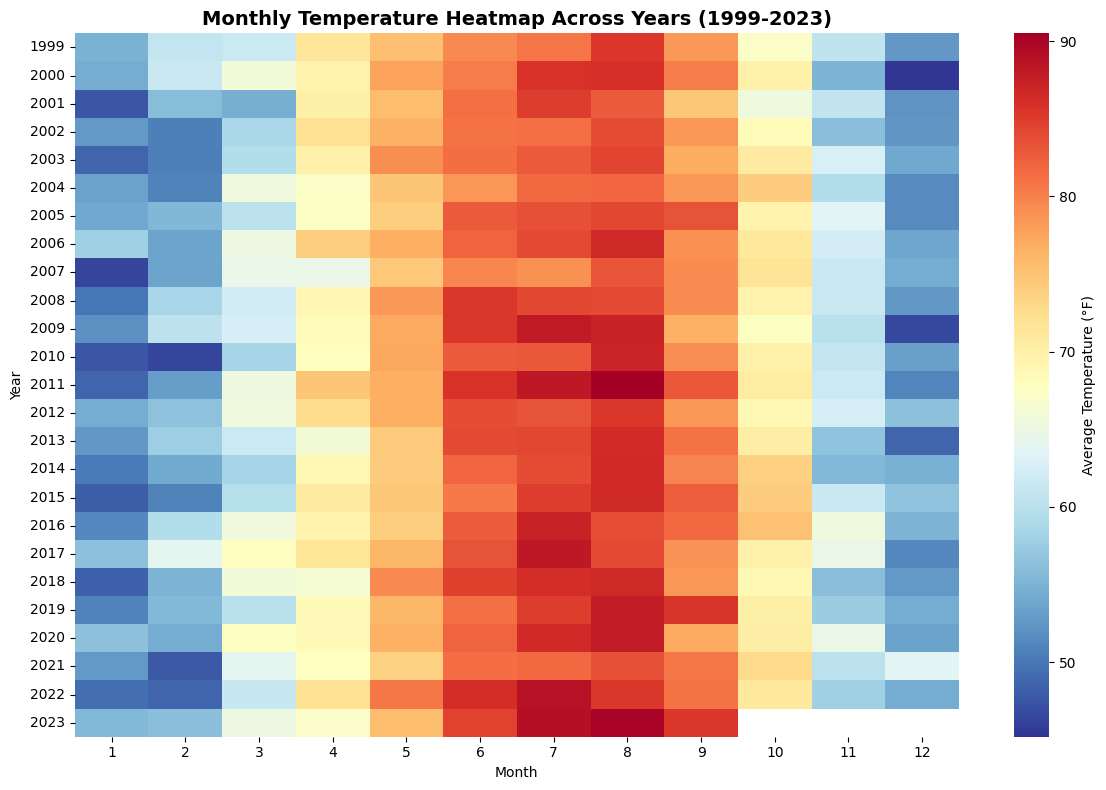

In [13]:
# Create a heatmap of monthly temperatures across years
plt.figure(figsize=(12, 8))

# Pivot data for heatmap
heatmap_data = monthly_comparison.pivot(index='Year', columns='Month', values='TempAvgF')

# Create heatmap
sns.heatmap(heatmap_data, annot=False, cmap='RdYlBu_r', cbar_kws={'label': 'Average Temperature (°F)'})
plt.title('Monthly Temperature Heatmap Across Years (1999-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()


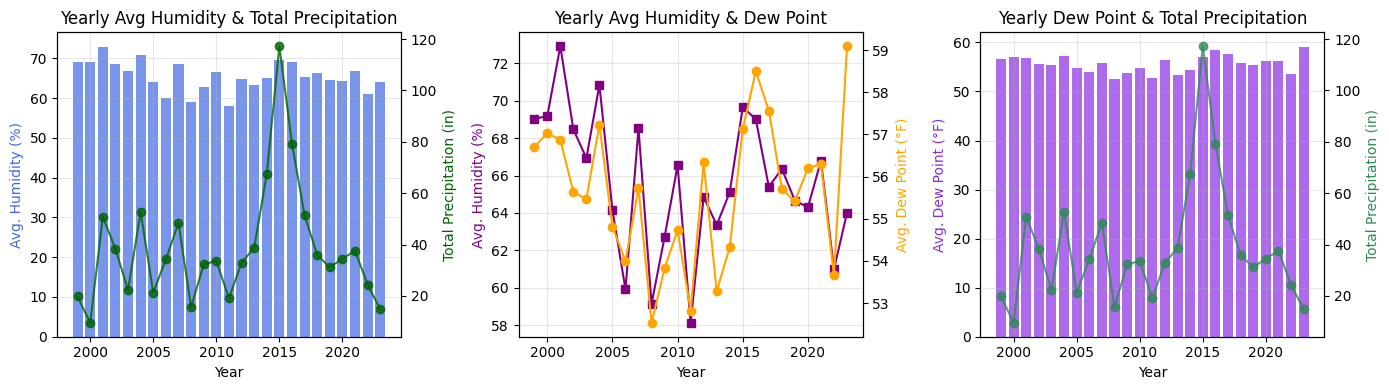

In [14]:
# Year-on-Year Analysis: Average Humidity, Dew Point, and Precipitation by Year

# Aggregate year-over-year data
yoy_year_summary = yoy_data.groupby('Year').agg({
    'HumidityAvgPercent': 'mean',
    'PrecipitationSumInches': 'sum',
    'DewPointAvgF': 'mean'
}).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Humidity vs. Precipitation (annual averages/sum by year)
axes[0].bar(yoy_year_summary['Year'], yoy_year_summary['HumidityAvgPercent'], color='royalblue', alpha=0.7, label='Avg. Humidity (%)')
ax2 = axes[0].twinx()
ax2.plot(yoy_year_summary['Year'], yoy_year_summary['PrecipitationSumInches'], color='darkgreen', marker='o', alpha=0.8, label='Total Precipitation (in)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Avg. Humidity (%)', color='royalblue')
ax2.set_ylabel('Total Precipitation (in)', color='darkgreen')
axes[0].set_title('Yearly Avg Humidity & Total Precipitation')
axes[0].grid(alpha=0.3)

# 2. Humidity vs. Dew Point (annual means)
axes[1].plot(yoy_year_summary['Year'], yoy_year_summary['HumidityAvgPercent'], color='purple', marker='s', label='Avg. Humidity (%)')
ax3 = axes[1].twinx()
ax3.plot(yoy_year_summary['Year'], yoy_year_summary['DewPointAvgF'], color='orange', marker='o', label='Avg. Dew Point (°F)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg. Humidity (%)', color='purple')
ax3.set_ylabel('Avg. Dew Point (°F)', color='orange')
axes[1].set_title('Yearly Avg Humidity & Dew Point')
axes[1].grid(alpha=0.3)

# 3. Dew Point vs. Precipitation (annual means/sum)
axes[2].bar(yoy_year_summary['Year'], yoy_year_summary['DewPointAvgF'], color='blueviolet', alpha=0.7, label='Avg. Dew Point (°F)')
ax4 = axes[2].twinx()
ax4.plot(yoy_year_summary['Year'], yoy_year_summary['PrecipitationSumInches'], color='seagreen', marker='o', alpha=0.8, label='Total Precipitation (in)')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Avg. Dew Point (°F)', color='blueviolet')
ax4.set_ylabel('Total Precipitation (in)', color='seagreen')
axes[2].set_title('Yearly Dew Point & Total Precipitation')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Step 9: Statistical Analysis of Temperature Changes


In [15]:
print("=== STATISTICAL ANALYSIS OF TEMPERATURE CHANGES ===")

# Calculate overall temperature trend
from scipy import stats

# Linear regression on annual temperatures
slope, intercept, r_value, p_value, std_err = stats.linregress(annual_temps['Year'], annual_temps['TempAvgF'])

print(f"Linear trend analysis:")
print(f"Slope (temperature change per year): {slope:.4f}°F/year")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Total change over 25 years: {slope * 25:.2f}°F")

# Calculate temperature statistics by decade
decade_stats = []
for decade in [1999, 2009, 2019]:
    decade_data = yoy_data[(yoy_data['Year'] >= decade) & (yoy_data['Year'] < decade + 10)]
    if len(decade_data) > 0:
        decade_stats.append({
            'Decade': f"{decade}s",
            'Avg_Temp': decade_data['TempAvgF'].mean(),
            'Max_Temp': decade_data['TempHighF'].max(),
            'Min_Temp': decade_data['TempLowF'].min(),
            'Temp_Range': decade_data['DailyTempRange'].mean()
        })

decade_df = pd.DataFrame(decade_stats)
print("\nTemperature statistics by decade:")
print(decade_df.round(2))

# Calculate hottest and coldest years
hottest_year = annual_temps.loc[annual_temps['TempAvgF'].idxmax()]
coldest_year = annual_temps.loc[annual_temps['TempAvgF'].idxmin()]

print(f"\nHottest year: {hottest_year['Year']} ({hottest_year['TempAvgF']:.2f}°F)")
print(f"Coldest year: {coldest_year['Year']} ({coldest_year['TempAvgF']:.2f}°F)")


=== STATISTICAL ANALYSIS OF TEMPERATURE CHANGES ===
Linear trend analysis:
Slope (temperature change per year): 0.1151°F/year
R-squared: 0.3139
P-value: 0.0036
Total change over 25 years: 2.88°F

Temperature statistics by decade:
  Decade  Avg_Temp  Max_Temp  Min_Temp  Temp_Range
0  1999s     68.71     109.8      21.4       20.52
1  2009s     69.71     110.4      16.1       20.65
2  2019s     70.49     108.1       8.2       20.92

Hottest year: 2023.0 (74.25°F)
Coldest year: 2001.0 (67.18°F)


## Step 10: Final Data Summary and Export


In [16]:
print("=== FINAL DATA SUMMARY ===")

print(f"Original dataset: {data.shape}")
print(f"Cleaned dataset: {data_features.shape}")
print(f"Features added: {data_features.shape[1] - data.shape[1]}")

print("\nData quality summary:")
print(f"Missing values: {data_features.isnull().sum().sum()}")
print(f"Date range: {data_features['Date'].min().strftime('%Y-%m-%d')} to {data_features['Date'].max().strftime('%Y-%m-%d')}")
print(f"Total days: {len(data_features)}")

print("\nTemperature statistics:")
print(f"Average temperature: {data_features['TempAvgF'].mean():.2f}°F")
print(f"Temperature range: {data_features['TempLowF'].min():.2f}°F to {data_features['TempHighF'].max():.2f}°F")
print(f"Average daily range: {data_features['DailyTempRange'].mean():.2f}°F")

print("\nData cleaning and feature engineering complete!")
print("Year-over-year analysis complete!")

# Export cleaned data
data_features.to_csv('Austin_Weather_Cleaned_99_23.csv', index=False)
print("\nCleaned data exported to 'Austin_Weather_Cleaned_99_23.csv'")


=== FINAL DATA SUMMARY ===
Original dataset: (10354, 10)
Cleaned dataset: (10354, 27)
Features added: 17

Data quality summary:
Missing values: 2
Date range: 1999-01-01 to 2023-09-26
Total days: 10354

Temperature statistics:
Average temperature: 69.49°F
Temperature range: 8.20°F to 110.40°F
Average daily range: 20.65°F

Data cleaning and feature engineering complete!
Year-over-year analysis complete!

Cleaned data exported to 'Austin_Weather_Cleaned_99_23.csv'



# Step 11: Correlation Analysis and Outlier Detection

<Axes: ylabel='TempAvgF'>

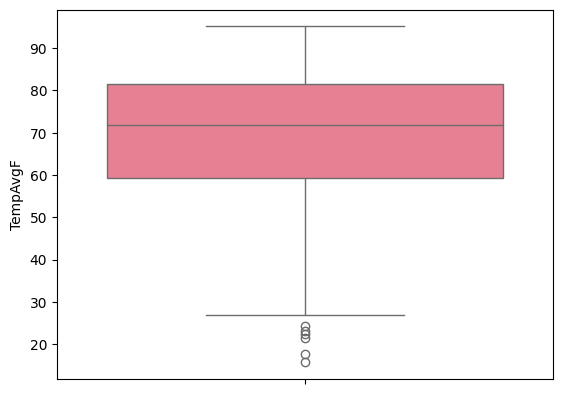

In [5]:
# We're going to detect outliers in some of the numeric features.
# We will not be removing them just yet since in some cases it is preffered to transform them rather than remove them.
df_clean=pd.read_csv('Austin_Weather_Cleaned_99_23.csv')
df_clean.head()
# First we will look at the avg. temp.
# The box plot of the data we previously clean is shown below to try and make some visual observations.
# We can visually see that there are likely some outliers at the "lower" end of the plot
sns.boxplot(df_clean['TempAvgF'])

In [6]:
# we're going to detect outliers using the IQR method
# we're going to define a function for this process to make it applicable to more feature in the future
def detect_outliers_iqr(x):
  q1=x.quantile(0.25)
  q3=x.quantile(0.75)
  iqr = q3-q1
  lb = q1 - 1.5*iqr
  up = q3 + 1.5*iqr
  return x[(x < lb) | (x > up)]
# for now we are just getting the outliers fo the avg temp F
outliers_avg_temp_f = detect_outliers_iqr(df_clean['TempAvgF'])
print(outliers_avg_temp_f)
# the printed outliers show the index and temp of the outliers
# the low temp values correspond with what we saw in the boxplot previously

4415     21.4
4416     23.2
9399     24.2
9400     15.7
9401     17.7
10076    22.5
Name: TempAvgF, dtype: float64


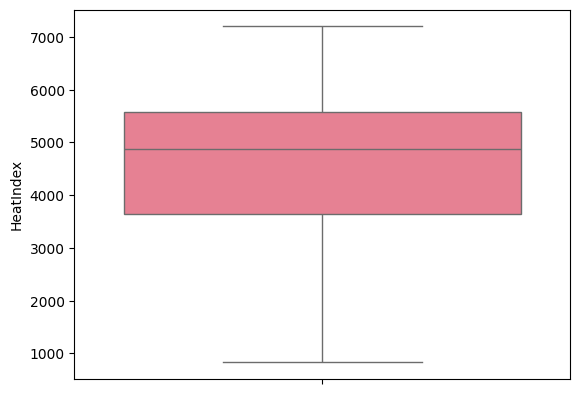

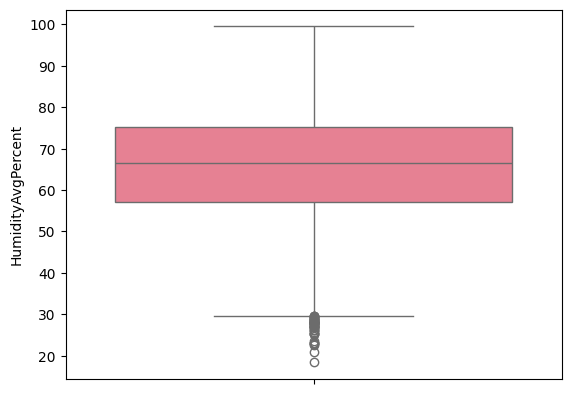

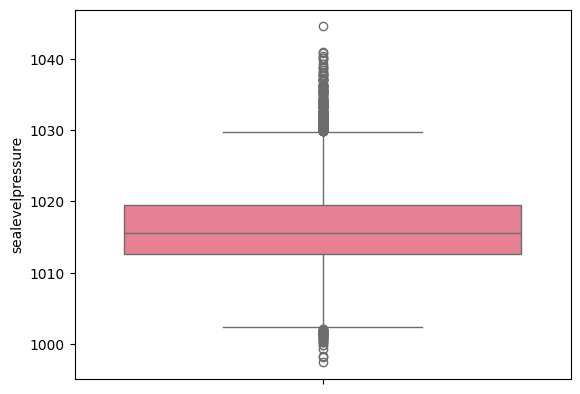

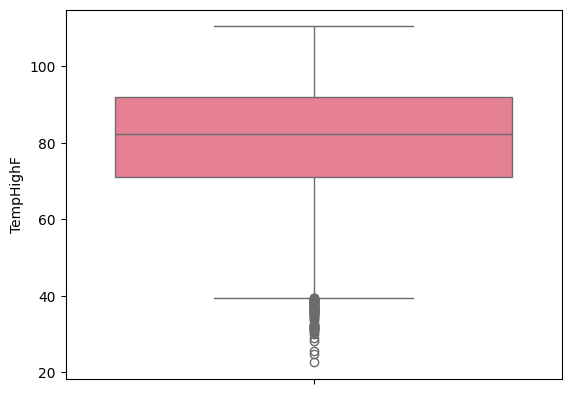

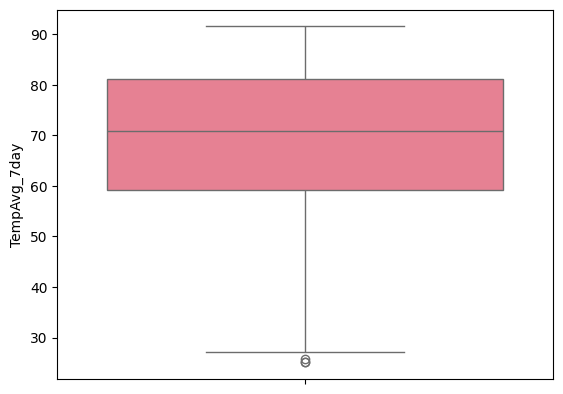

In [7]:
# Now we will look at the following columns as well, based on the research document provided to know what's important for heat related illnesses
# HeatIndex	(this directly represents the perceived heat stress)
# HumidityAvgPercent (controls the body’s cooling efficiency)
# sealevelpressure	(it detects stagnant heat-domes)
# TempHighF (since it's the most extreme daily exposure)
# TempAvg_7day	(this measures prolonged heat exposures)

plt.figure()
sns.boxplot(df_clean['HeatIndex'])
outliers_HI = detect_outliers_iqr(df_clean['HeatIndex'])

plt.figure()
sns.boxplot(df_clean['HumidityAvgPercent'])
outliers_Hum_avg_perc = detect_outliers_iqr(df_clean['HumidityAvgPercent'])

plt.figure()
sns.boxplot(df_clean['sealevelpressure'])
outliers_sea_lvl_pr = detect_outliers_iqr(df_clean['sealevelpressure'])

plt.figure()
sns.boxplot(df_clean['TempHighF'])
outliers_tmp_H_F = detect_outliers_iqr(df_clean['TempHighF'])

plt.figure()
sns.boxplot(df_clean['TempAvg_7day'])
plt.show()
outliers_tmp_avg_7 = detect_outliers_iqr(df_clean['TempAvg_7day'])

outliers_all = [outliers_avg_temp_f,outliers_HI,outliers_Hum_avg_perc,outliers_sea_lvl_pr,outliers_tmp_H_F,outliers_tmp_avg_7,outliers_tmp_avg_7]

# something we can specifically notice here is that some columns have a lot more rows classified as outliers than others.
# it could be worthwhile to look at why that is and whether we can actually consider them outliers or if it's actually representative of some other pattern.


<Axes: >

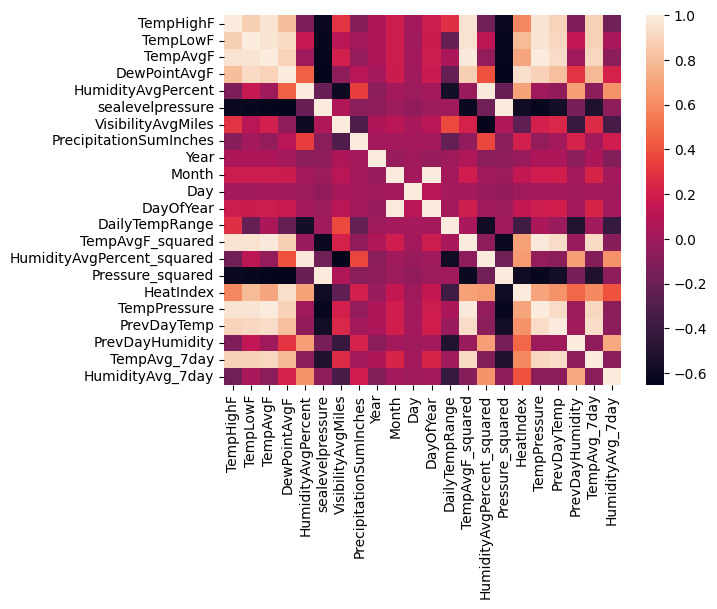

In [8]:
# now we're going to go into correlation analysis
# first we are going to get just the numeric columns of interest
df_numeric = df_clean.select_dtypes(include = "number")
df_numeric.head()
corr_mat_all = df_numeric.corr('pearson')
sns.heatmap(corr_mat_all,annot=False)

<Axes: >

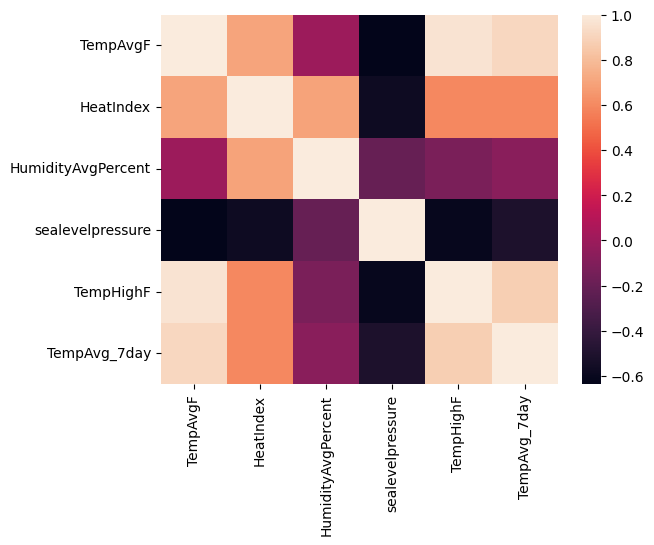

In [13]:
# this has a lot going on so we are going to narrow it down to the columns we looked at for outliers
cols = ['TempAvgF','HeatIndex','HumidityAvgPercent','sealevelpressure','TempHighF','TempAvg_7day']
corr_mat_interest = df_clean[cols].corr('pearson')
sns.heatmap(corr_mat_interest, annot=False)
# We could also look into some of the other correlation coefficients that we didn't visualize here to see their possible relationships,
# just narrowed it down to these since it felt relavent.


Summary of what is done:

I focused on outlier detection and correlation analysis. For the outlier detection I focused on what columns seemed most relavent based on things mentioned in the google doc provided that contained background research. Some had a lot of outliers, though, so it might be beneficial to look further in and do something with them rather than just delete.
For the correlation analysis I focused on those same columns. Here I used the pearson method. Some of the relationships that we see do make sense with what seems intuitive, like the heat index and temp ones for example. We do need to keep in mind how the outliers are influencing these numbers and that relationships may not be linear.